# Five-minute unfiltered Hall-array acquisition and PSD

This notebook records all 36 channels for 300 seconds, converts the received ADC values directly to volts, and computes ensemble averages and PSDs from the board's natural output voltage.

All saved data, plots, ensemble averages, and PSDs use the board's natural output voltage. No DC removal, moving average, smoothing, windowing, or Welch averaging is applied.

**Hardware limitation:** the current camera firmware calls `super_frame(frame, 64)`, so every transmitted frame is already the average of 64 ADC scans. That device-side averaging cannot be undone here without changing and reflashing the firmware.

## 1. Imports and acquisition settings

Run the notebook with an environment containing NumPy, Matplotlib, pySerial, and Jupyter. Change `PORT` if the array appears under another serial-device name. Leave `SAMPLE_RATE_HZ = None` to estimate the transmitted-frame rate from the five-minute capture. If you have independently measured the exact frame rate, enter it instead for the most accurate PSD frequency axis.

In [1]:
from pathlib import Path
from collections import deque
from datetime import datetime, timezone
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pyqtgraph as pg
import serial
from PyQt6.QtWidgets import (
    QApplication, QMainWindow, QWidget, QVBoxLayout, QHBoxLayout,
    QPushButton, QLabel,
)

PORT = "/dev/ttyACM0"
BAUDRATE = 921600
SAMPLE_RATE_HZ = None  # None = estimate the output-frame rate from the capture

NUM_CHANNELS = 36
SYNC_BYTES = b"\xAA\x55\xAA\x55"
PAYLOAD_SIZE = NUM_CHANNELS * 2
RAW_SHIFT = 4
V_REF = 5.0
ADC_FULL_SCALE = 1 << 12
VOLTS_PER_COUNT = V_REF / ADC_FULL_SCALE



OUTPUT_DIR = Path("hall_array_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print(f"Results will be written to: {OUTPUT_DIR.resolve()}")

Results will be written to: /home/hamid/SuperHallArray/hall_array_output


## 2. Frame parser and five-minute capture

The parser uses the same byte-accurate synchronization and ADC scaling as the viewer. The serial input buffer is cleared immediately before acquisition so old frames are not included. Stop the cell with the notebook interrupt button if necessary; the serial port is still closed by the `finally` block.

In [2]:
class FrameParser:
    def __init__(self):
        self.buffer = bytearray()

    def feed(self, chunk):
        self.buffer.extend(chunk)
        frames = []
        frame_size = len(SYNC_BYTES) + PAYLOAD_SIZE

        while True:
            sync_index = self.buffer.find(SYNC_BYTES)
            if sync_index < 0:
                keep = len(SYNC_BYTES) - 1
                if len(self.buffer) > keep:
                    del self.buffer[:-keep]
                break
            if len(self.buffer) - sync_index < frame_size:
                del self.buffer[:sync_index]
                break

            payload_start = sync_index + len(SYNC_BYTES)
            payload_end = payload_start + PAYLOAD_SIZE
            wire_values = np.frombuffer(
                bytes(self.buffer[payload_start:payload_end]), dtype="<u2"
            ).copy()
            del self.buffer[:payload_end]
            frames.append(wire_values)

        return frames


class RawLiveSignalWindow:
    """Live display of raw transmitted frames; history is not averaged."""

    def __init__(self, title, history_length=800):
        self.app = QApplication.instance() or QApplication([])
        self.history = np.full((history_length, NUM_CHANNELS), np.nan)
        self.window = pg.GraphicsLayoutWidget(show=True, title=title)
        self.window.resize(1200, 700)
        self.plot = self.window.addPlot(title=title)
        self.plot.setLabel("bottom", "Raw transmitted frame")
        self.plot.setLabel("left", "Natural V_out [V]")
        self.plot.showGrid(x=True, y=True, alpha=0.25)
        colors = [pg.intColor(index, hues=NUM_CHANNELS) for index in range(NUM_CHANNELS)]
        self.curves = [self.plot.plot(pen=pg.mkPen(color, width=1)) for color in colors]
        self.app.processEvents()

    def update(self, wire_frame):
        raw_voltage_v = (
            wire_frame.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
        )
        self.history[:-1] = self.history[1:]
        self.history[-1] = raw_voltage_v
        for channel, curve in enumerate(self.curves):
            curve.setData(self.history[:, channel])
        self.app.processEvents()

    def close(self):
        self.window.close()
        self.app.processEvents()


class SensitivityLiveSignalWindow(RawLiveSignalWindow):
    """Baseline-referenced, rolling-display viewer for weak-field alignment."""

    def __init__(self, title, calibration_frames=500, display_window_frames=64):
        super().__init__(title)
        self.calibration_frames = calibration_frames
        self.display_window_frames = display_window_frames
        self.calibration_samples = []
        self.baseline_v = None
        self.display_samples = deque(maxlen=display_window_frames)
        self.plot.setLabel("left", "Baseline-referenced V_out [V]")
        self.plot.setTitle("Collecting baseline: keep magnet at 50 cm")

    @property
    def calibrated(self):
        return self.baseline_v is not None

    def update(self, wire_frame):
        raw_voltage_v = (
            wire_frame.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
        )
        if not self.calibrated:
            self.calibration_samples.append(raw_voltage_v)
            if len(self.calibration_samples) >= self.calibration_frames:
                self.baseline_v = np.mean(self.calibration_samples, axis=0)
                self.plot.setTitle(
                    f"Baseline set. Live display: {self.display_window_frames}-frame rolling average"
                )
            self.app.processEvents()
            return

        # This average is display-only. Raw values remain the saved measurements.
        self.display_samples.append(raw_voltage_v - self.baseline_v)
        display_voltage_v = np.mean(self.display_samples, axis=0)
        self.history[:-1] = self.history[1:]
        self.history[-1] = display_voltage_v
        for channel, curve in enumerate(self.curves):
            curve.setData(self.history[:, channel])
        self.app.processEvents()


In [ ]:
DURATION_S = 5 * 60
def acquire_frames(port, baudrate, duration_s):
    parser = FrameParser()
    wire_frames = []
    arrival_times_s = []

    with serial.Serial(port, baudrate, timeout=0.1) as ser:
        ser.reset_input_buffer()
        # This window displays the raw received frames; it does not average them.
        global five_minute_live_viewer
        five_minute_live_viewer = RawLiveSignalWindow(
            "Live raw Hall-array signals — five-minute capture"
        )
        start = time.perf_counter()
        next_report = start + 10

        while True:
            now = time.perf_counter()
            if now - start >= duration_s:
                break

            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                parsed = parser.feed(chunk)
                received_at = time.perf_counter() - start
                for raw_frame in parsed:
                    five_minute_live_viewer.update(raw_frame)
                wire_frames.extend(parsed)
                arrival_times_s.extend([received_at] * len(parsed))

            if now >= next_report:
                elapsed = now - start
                print(
                    f"{elapsed:6.1f}/{duration_s:.0f} s, "
                    f"{len(wire_frames):,} frames received"
                )
                next_report += 10.0

        capture_elapsed_s = time.perf_counter() - start

    if len(wire_frames) < 2:
        raise RuntimeError(
            f"Only {len(wire_frames)} frame(s) were received from {port}. "
            "Check the port, firmware mode, and USB connection."
        )

    return (
        np.asarray(wire_frames, dtype=np.uint16),
        np.asarray(arrival_times_s, dtype=np.float64),
        capture_elapsed_s,
    )


wire_values, arrival_times_s, capture_elapsed_s = acquire_frames(
    PORT, BAUDRATE, DURATION_S
)

# Q4 wire values -> fractional 12-bit ADC counts -> physical output volts.
# This is direct scaling only: no baseline removal and no host-side filtering.
adc_counts = wire_values.astype(np.float64) / (1 << RAW_SHIFT)
voltage_out = adc_counts * VOLTS_PER_COUNT

if SAMPLE_RATE_HZ is None:
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_hz = measured_sample_rate_hz
    sample_rate_source = "estimated from host arrival time"
else:
    sample_rate_hz = float(SAMPLE_RATE_HZ)
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_source = "user supplied"

if not np.isfinite(sample_rate_hz) or sample_rate_hz <= 0:
    raise RuntimeError(f"Invalid sample rate: {sample_rate_hz}")

# Frames do not contain device timestamps. Use a uniform time base at the selected
# output-frame rate, as required by the FFT PSD.
time_s = np.arange(len(voltage_out), dtype=np.float64) / sample_rate_hz

print(f"Captured {len(voltage_out):,} frames in {capture_elapsed_s:.3f} s")
print(f"Measured output-frame rate: {measured_sample_rate_hz:.6f} Hz")
print(f"PSD/time-axis rate: {sample_rate_hz:.6f} Hz ({sample_rate_source})")
print(f"Voltage array shape: {voltage_out.shape}")

## 3. Save the natural board-voltage samples

The natural-voltage time series is saved as CSV. No NPZ files are written.

In [ ]:
csv_path = OUTPUT_DIR / "hall_array_5min_unfiltered.csv"
csv_data = np.column_stack((time_s, voltage_out))
csv_header = "time_s," + ",".join(
    f"pad_{index:02d}_voltage_out_v" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(csv_path, csv_data, delimiter=",", header=csv_header, comments="")

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "port": PORT,
    "baudrate": BAUDRATE,
    "requested_duration_s": DURATION_S,
    "actual_capture_elapsed_s": capture_elapsed_s,
    "number_of_frames": len(voltage_out),
    "number_of_channels": NUM_CHANNELS,
    "measured_output_frame_rate_hz": measured_sample_rate_hz,
    "psd_sample_rate_hz": sample_rate_hz,
    "sample_rate_source": sample_rate_source,
    "volts_per_adc_count": VOLTS_PER_COUNT,
    "host_filtering": "none",
    "baseline_subtracted": False,
    "firmware_note": "Current camera firmware averages 64 ADC scans per transmitted frame.",
}
metadata_path = OUTPUT_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")

print(f"Saved {csv_path}")
print(f"Saved {metadata_path}")

## 4. Plot and save natural voltage versus time for all 36 pads

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(time_s, voltage_out[:, channel], linewidth=0.55)
    ax.set_title(f"Pad {channel + 1}", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    if channel // 6 == 5:
        ax.set_xlabel("Time [s]")
    if channel % 6 == 0:
        ax.set_ylabel("Voltage out [V]")

fig.suptitle(
    f"Natural Hall-array voltage — {capture_elapsed_s:.1f} s capture",
    fontsize=15,
)
timeseries_plot_path = OUTPUT_DIR / "voltage_out_36_pads_5min.png"
fig.savefig(timeseries_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {timeseries_plot_path}")

### Natural voltage comparison in one time-series plot

This plot overlays the natural output voltage of all 36 pads, including their stable approximately 2.5 V offsets.

In [ ]:
# Plot the natural output voltage of all 36 pads on one set of axes.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        time_s,
        voltage_out[:, channel],
        color=color,
        linewidth=0.7,
        alpha=0.8,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Natural $V_{out}$ [V]")
ax.set_title("Natural voltage versus time for all 36 Hall-array pads")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

actual_voltage_plot_path = OUTPUT_DIR / "natural_voltage_all_36_pads_timeseries.png"
fig.savefig(actual_voltage_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {actual_voltage_plot_path}")

## 5. Ensemble average of all 36 pads

At every time point, the ensemble output is the equal-weight arithmetic mean of the 36 simultaneous natural pad voltages. This is an average across pads, not a moving average across time.

In [ ]:
# Ensemble average across the 36 pads for every acquired frame.
ensemble_average_v = voltage_out.mean(axis=1)

# Save the exact time and ensemble-average values used in the plot.
ensemble_csv_path = OUTPUT_DIR / "ensemble_average_36_pads.csv"
ensemble_table = np.column_stack((time_s, ensemble_average_v))
np.savetxt(
    ensemble_csv_path,
    ensemble_table,
    delimiter=",",
    header="time_s,ensemble_average_voltage_v",
    comments="",
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(time_s, ensemble_average_v, color="blue", linewidth=0.9)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Ensemble-average $V_{out}$ [V]")
ax.set_title("Ensemble average of all 36 natural Hall-array pads")
ax.grid(True, alpha=0.3)

ensemble_plot_path = OUTPUT_DIR / "ensemble_average_36_pads.png"
fig.savefig(ensemble_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Ensemble mean: {ensemble_average_v.mean():.6f} V")
print(f"Saved {ensemble_csv_path}")
print(f"Saved {ensemble_plot_path}")

## 6. PSD of the natural 36-pad ensemble average

This cell plots power spectral density in V²/Hz versus frequency for the ensemble average of the natural pad voltages.

In [ ]:
# Use the natural ensemble-average voltage without DC removal.
ensemble_signal_v = ensemble_average_v
ensemble_sample_count = len(ensemble_signal_v)
ensemble_frequency_hz = np.fft.rfftfreq(
    ensemble_sample_count, d=1.0 / sample_rate_hz
)
ensemble_fft = np.fft.rfft(ensemble_signal_v)
ensemble_psd_v2_per_hz = (np.abs(ensemble_fft) ** 2) / (
    sample_rate_hz * ensemble_sample_count
)

# Convert to a one-sided PSD. DC and Nyquist are not doubled.
if ensemble_sample_count % 2 == 0:
    ensemble_psd_v2_per_hz[1:-1] *= 2.0
else:
    ensemble_psd_v2_per_hz[1:] *= 2.0
ensemble_psd_v2_per_hz = np.maximum(ensemble_psd_v2_per_hz, 0.0)

# Save exactly the same frequency and V²/Hz values used in the plot.
ensemble_psd_csv_path = OUTPUT_DIR / "ensemble_average_psd.csv"
np.savetxt(
    ensemble_psd_csv_path,
    np.column_stack((ensemble_frequency_hz, ensemble_psd_v2_per_hz)),
    delimiter=",",
    header="frequency_hz,ensemble_average_psd_v2_per_hz",
    comments="",
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(ensemble_frequency_hz, ensemble_psd_v2_per_hz, color="blue", linewidth=0.9)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Ensemble-average PSD [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title("PSD of the natural 36-pad ensemble-average voltage")
ax.grid(True, alpha=0.3)

ensemble_psd_plot_path = OUTPUT_DIR / "ensemble_average_psd.png"
fig.savefig(ensemble_psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {ensemble_psd_csv_path}")
print(f"Saved {ensemble_psd_plot_path}")

## 7. Calculate PSD for all 36 natural pad voltages

The natural pad voltages are used directly for the individual-channel PSD calculation. The 0 Hz component therefore includes the stable board-voltage offset.

In [ ]:
# Use the natural board-voltage samples directly; no DC removal or filtering.
voltage_for_psd_v = voltage_out
print("Using natural board-voltage samples; no DC removal or filtering.")

In [ ]:
# Calculate a one-sided PSD directly from the complete natural-voltage recording.
# This is a single FFT periodogram: no Welch/segment averaging or smoothing.
number_of_samples = len(voltage_for_psd_v)
psd_frequency_hz = np.fft.rfftfreq(number_of_samples, d=1.0 / sample_rate_hz)
voltage_fft = np.fft.rfft(voltage_for_psd_v, axis=0)
psd_v2_per_hz = (np.abs(voltage_fft) ** 2) / (sample_rate_hz * number_of_samples)

# Convert the two-sided result to a one-sided PSD. DC and Nyquist are not doubled.
if number_of_samples % 2 == 0:
    psd_v2_per_hz[1:-1] *= 2.0
else:
    psd_v2_per_hz[1:] *= 2.0
psd_v2_per_hz = np.maximum(psd_v2_per_hz, 0.0)

# Save the exact same frequency and PSD arrays used by the plot below.
psd_csv_path = OUTPUT_DIR / "psd_36_pads.csv"
psd_table = np.column_stack((psd_frequency_hz, psd_v2_per_hz))
psd_header = "frequency_hz," + ",".join(
    f"pad_{index:02d}_psd_v2_per_hz" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(psd_csv_path, psd_table, delimiter=",", header=psd_header, comments="")

print(f"Frequency-bin spacing: {psd_frequency_hz[1] - psd_frequency_hz[0]:.6g} Hz")
print(f"Saved {psd_csv_path}")

## 8. Plot PSD for all 36 pads

This plot overlays the saved PSD of all 36 pads. Its unit is V²/Hz and it includes the natural stable DC voltage at 0 Hz.

In [ ]:
# Plot the PSD arrays saved by the preceding cell.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        psd_frequency_hz,
        psd_v2_per_hz[:, channel],
        color=color,
        linewidth=1.0,
        alpha=0.85,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD of $V_{out}$ [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title(f"Unaveraged PSD of all 36 natural Hall-array voltages (fs = {sample_rate_hz:.3f} Hz)")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

psd_plot_path = OUTPUT_DIR / "psd_36_pads.png"
fig.savefig(psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {psd_plot_path}")

## 9. Magnetic field sensitivity measurement

Keep the magnet at 50 cm while the live-display baseline is collected.
[1/10] MOVE magnet to 30 cm NOW. Recording in 2 seconds...
Recorded 30 cm using 28 frame(s).
[2/10] MOVE magnet to 27 cm NOW. Recording in 2 seconds...
Recorded 27 cm using 50 frame(s).
[3/10] MOVE magnet to 24 cm NOW. Recording in 2 seconds...
Recorded 24 cm using 58 frame(s).
[4/10] MOVE magnet to 21 cm NOW. Recording in 2 seconds...
Recorded 21 cm using 81 frame(s).
[5/10] MOVE magnet to 18 cm NOW. Recording in 2 seconds...
Recorded 18 cm using 81 frame(s).
[6/10] MOVE magnet to 15 cm NOW. Recording in 2 seconds...
Recorded 15 cm using 28 frame(s).
[7/10] MOVE magnet to 12 cm NOW. Recording in 2 seconds...
Recorded 12 cm using 35 frame(s).
[8/10] MOVE magnet to 9 cm NOW. Recording in 2 seconds...
Recorded 9 cm using 62 frame(s).
[9/10] MOVE magnet to 6 cm NOW. Recording in 2 seconds...
Recorded 6 cm using 80 frame(s).
[10/10] MOVE magnet to 3 cm NOW. Recording in 2 seconds...
Recorded 3 cm using 42 frame(s).


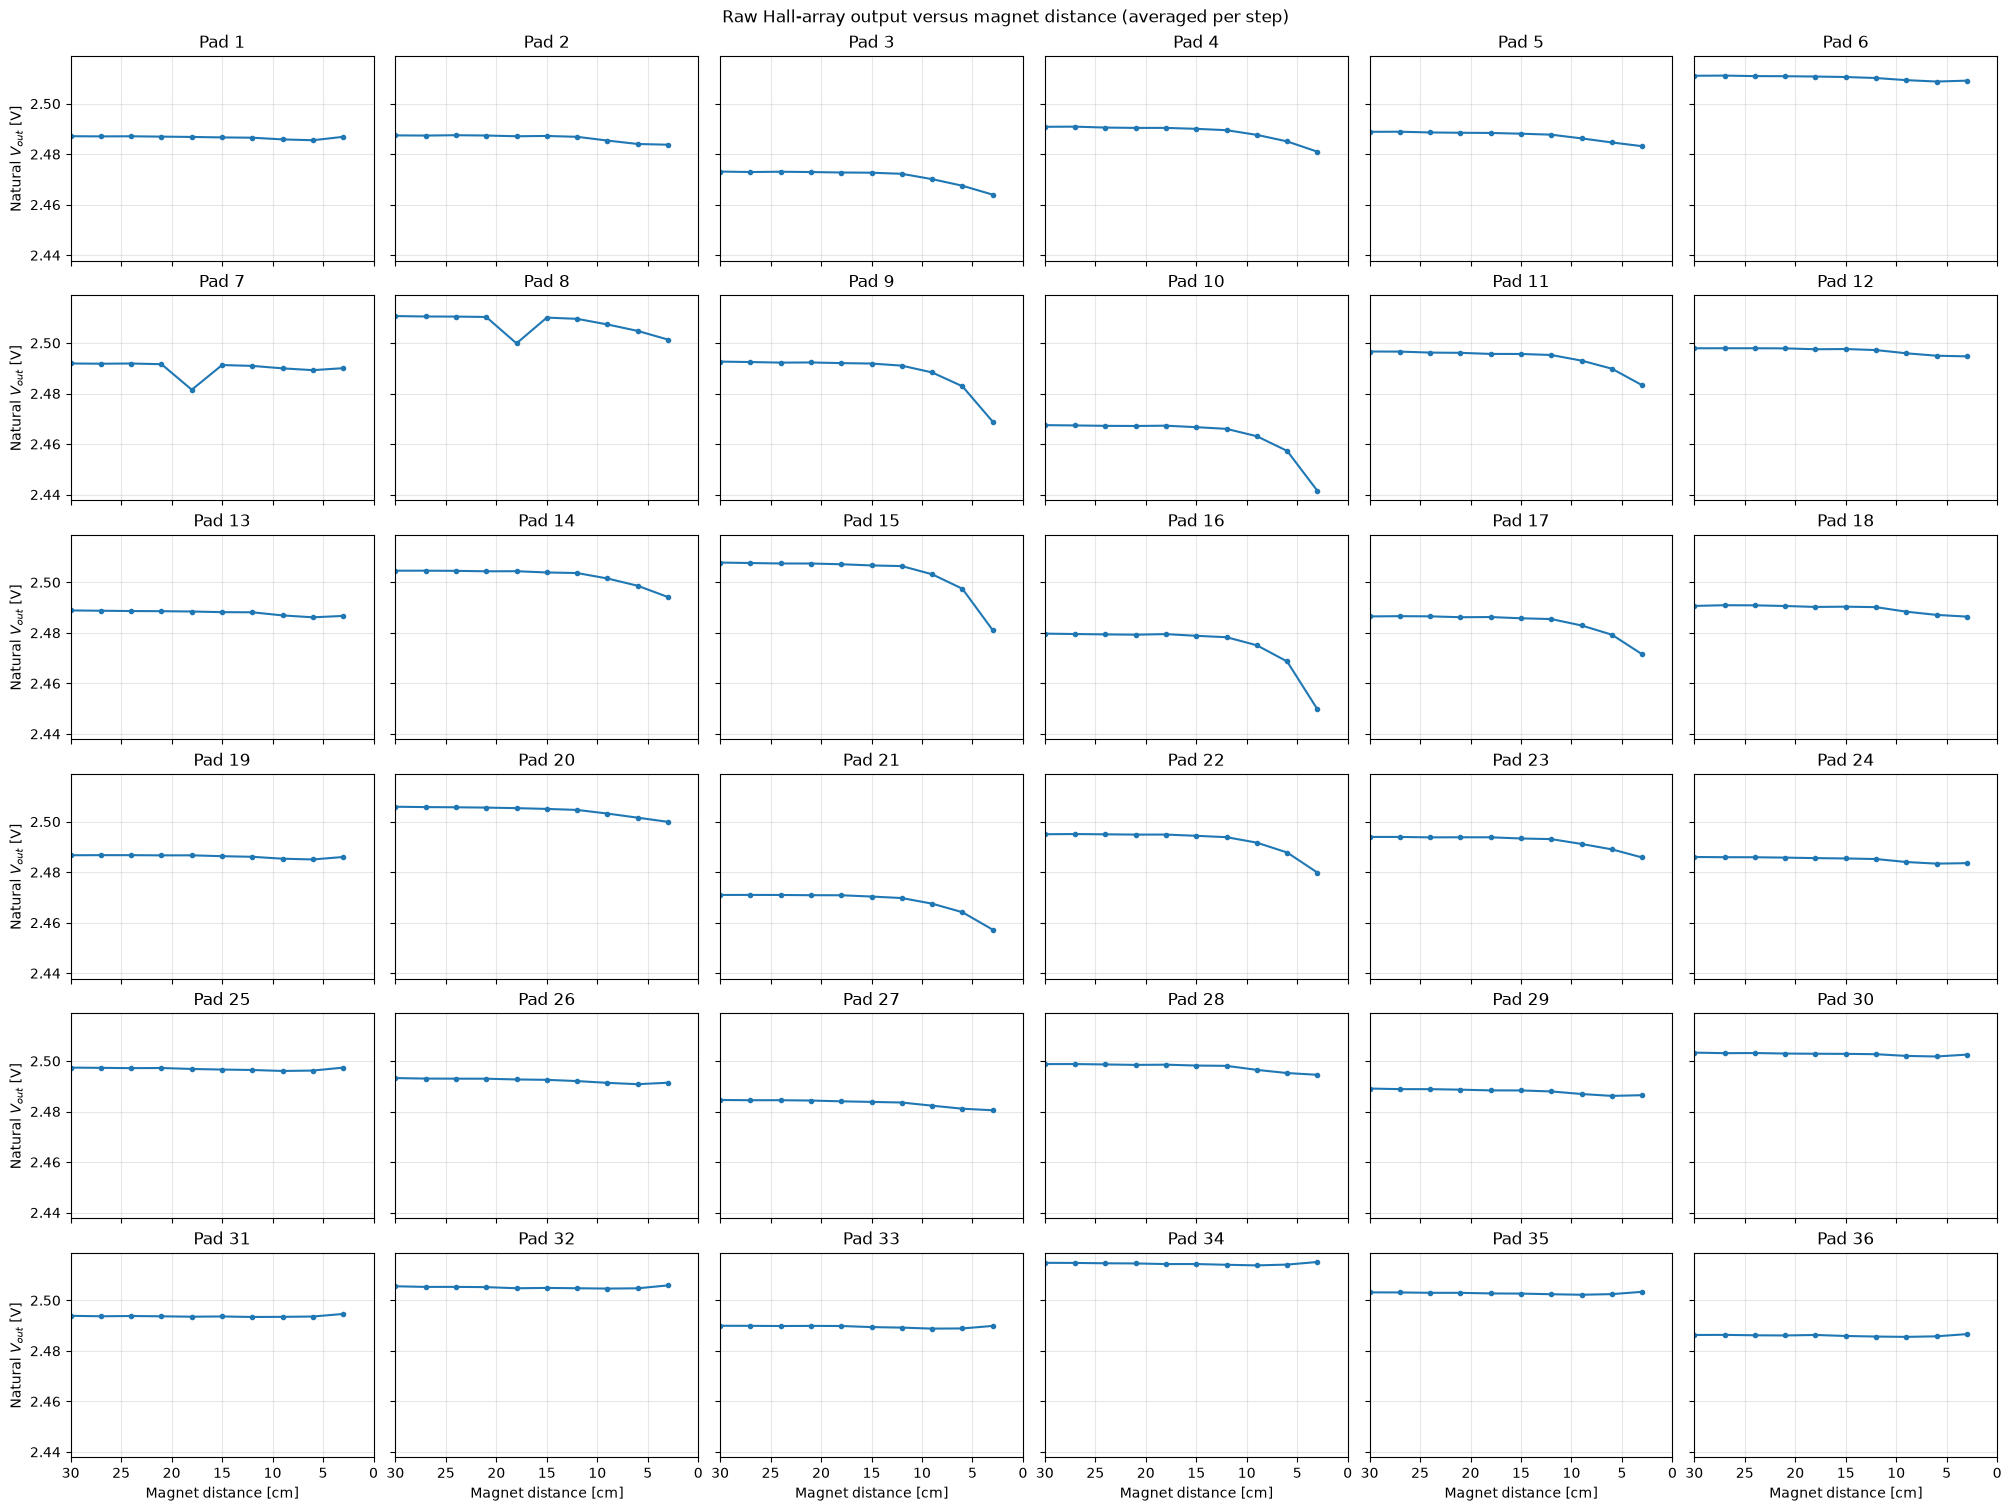

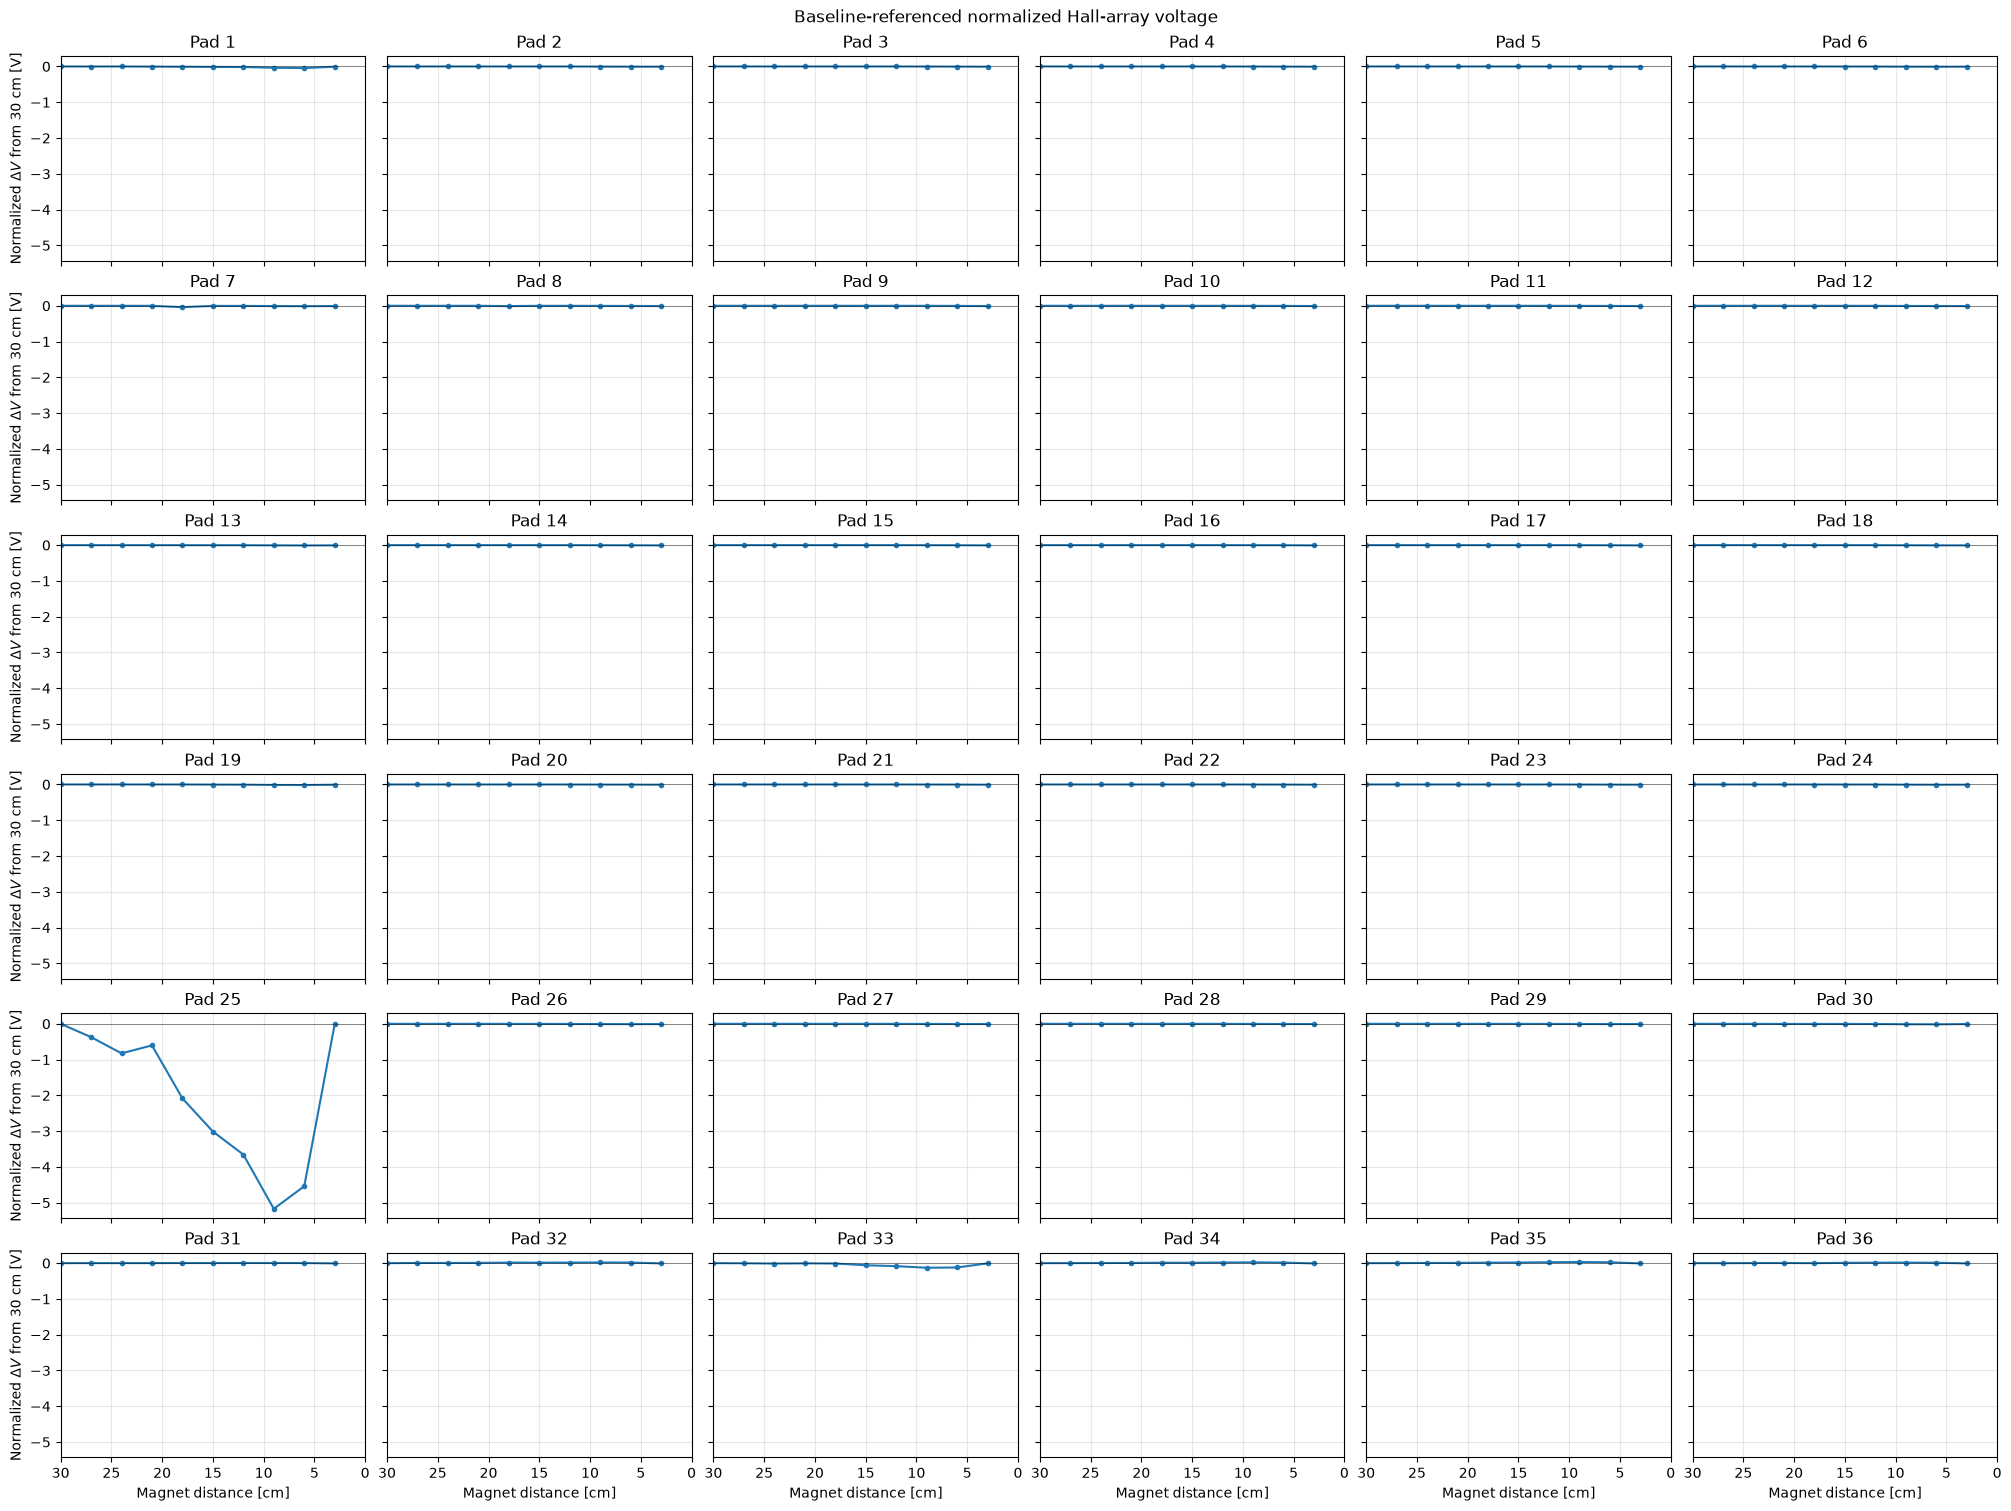

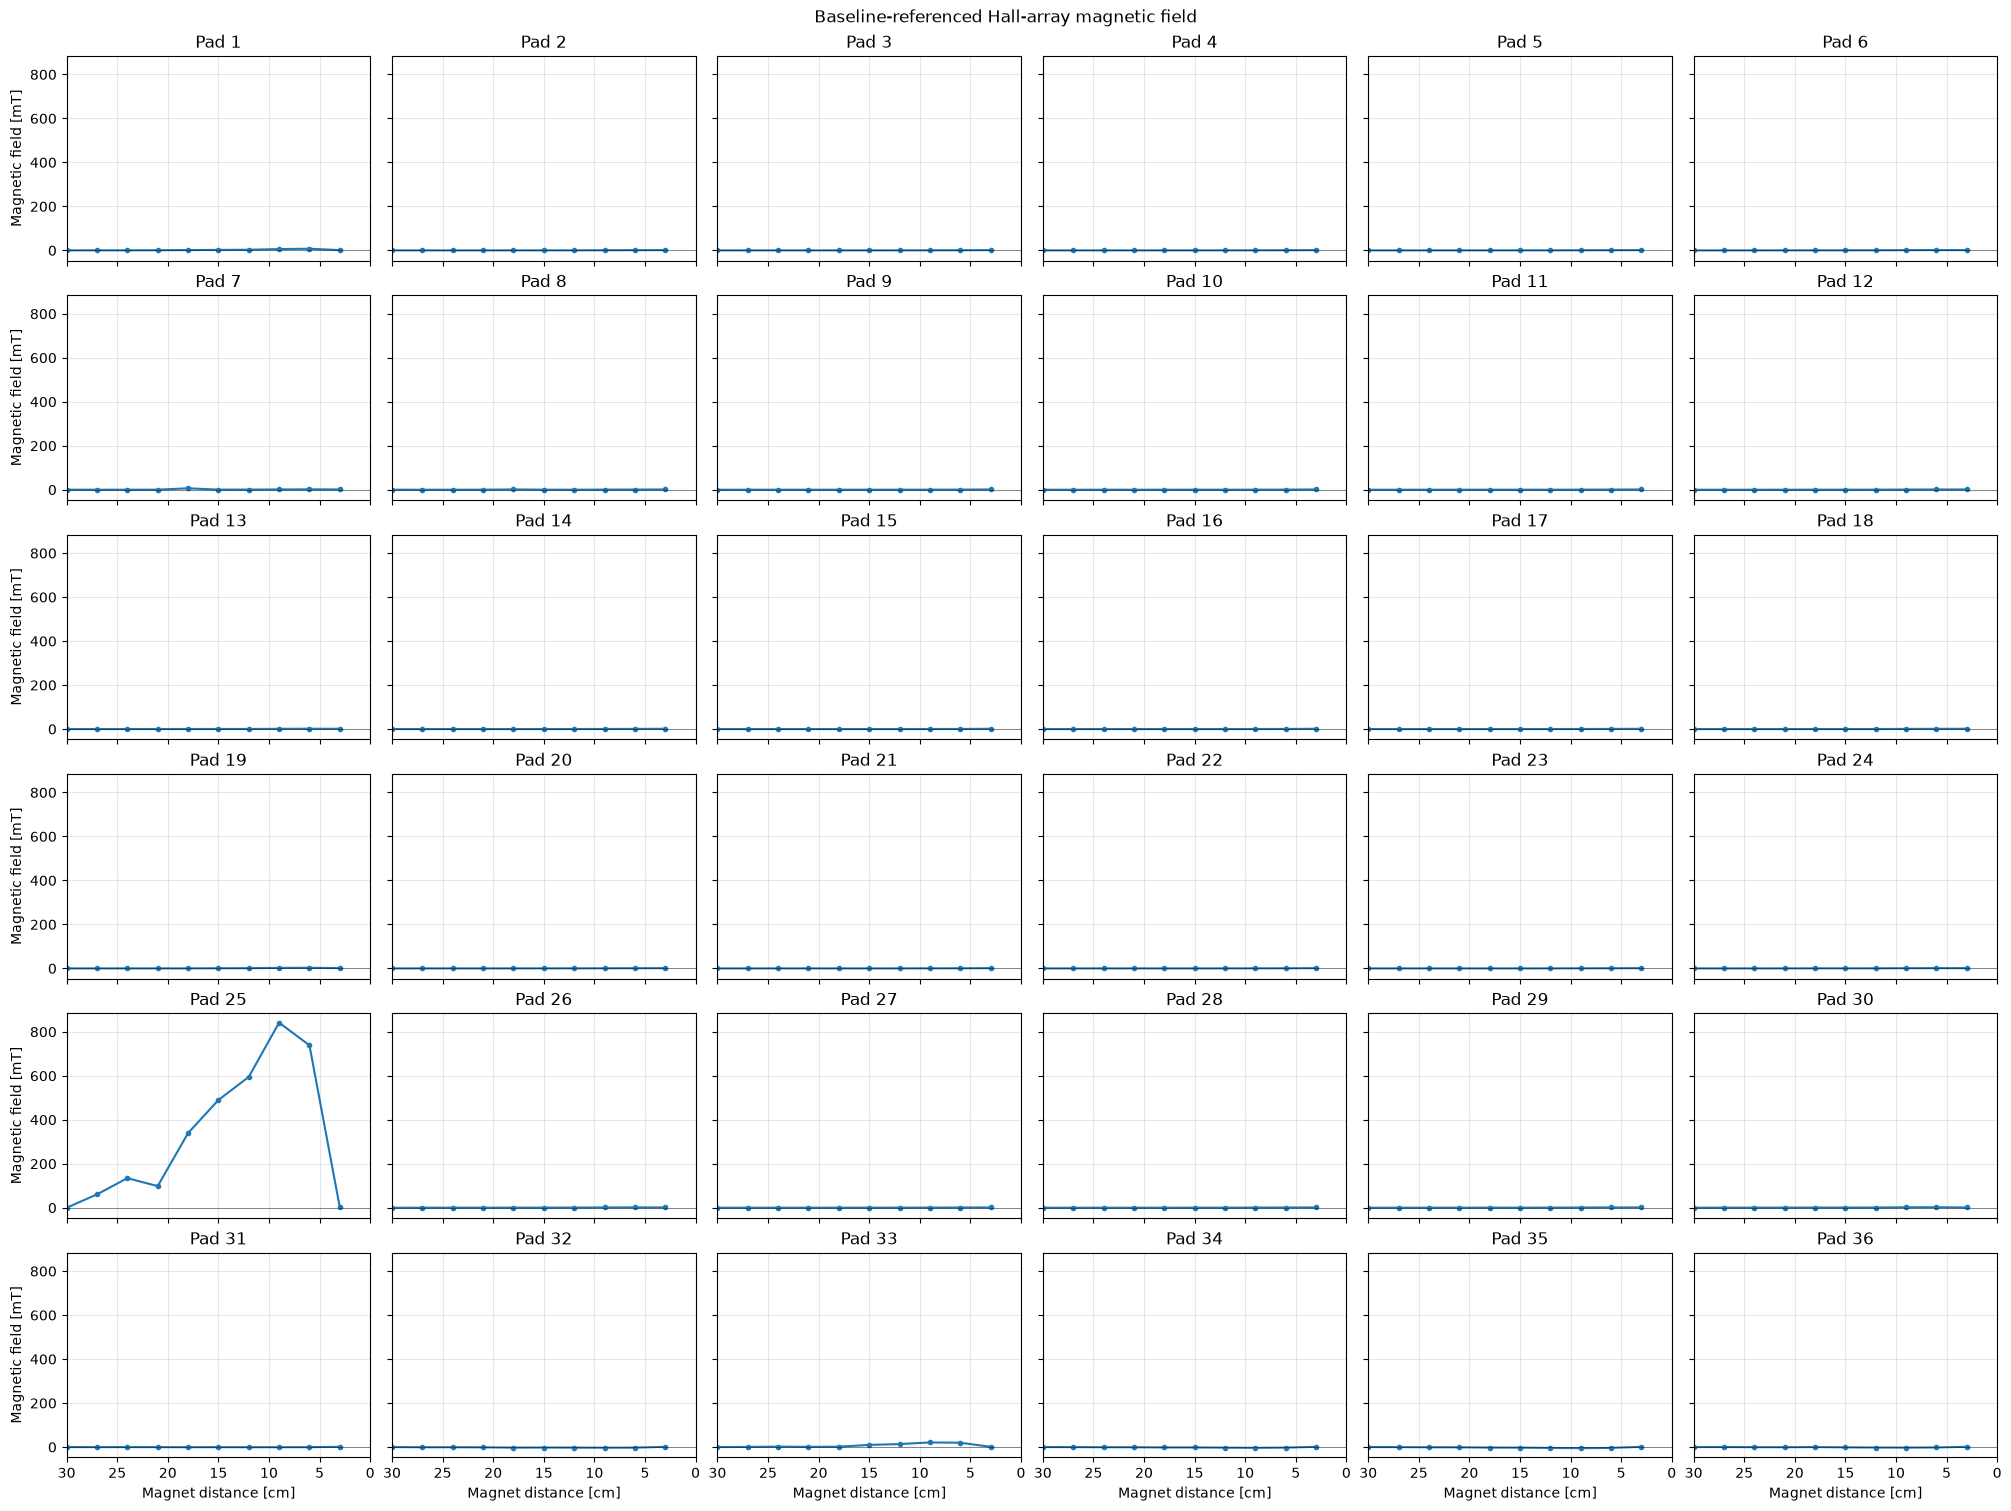

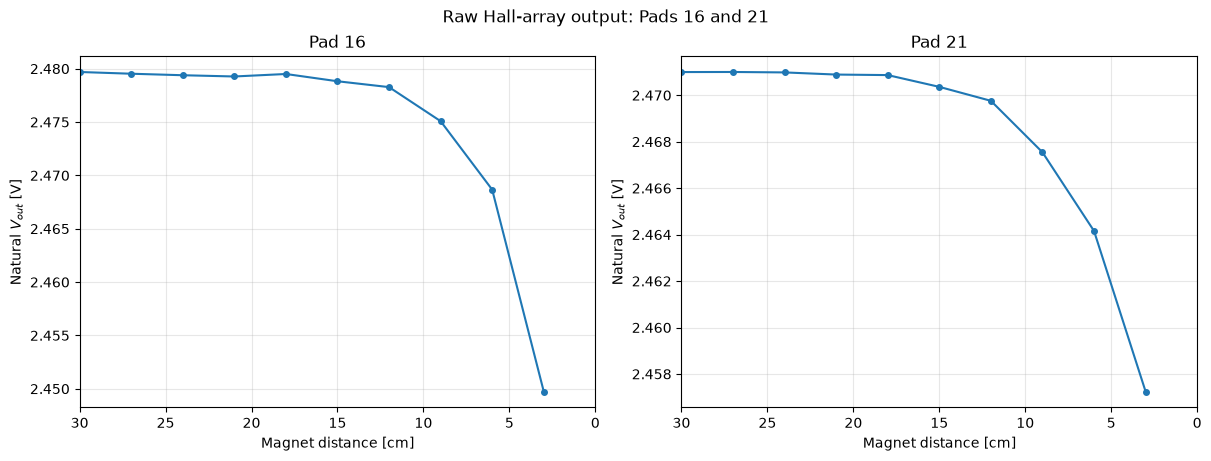

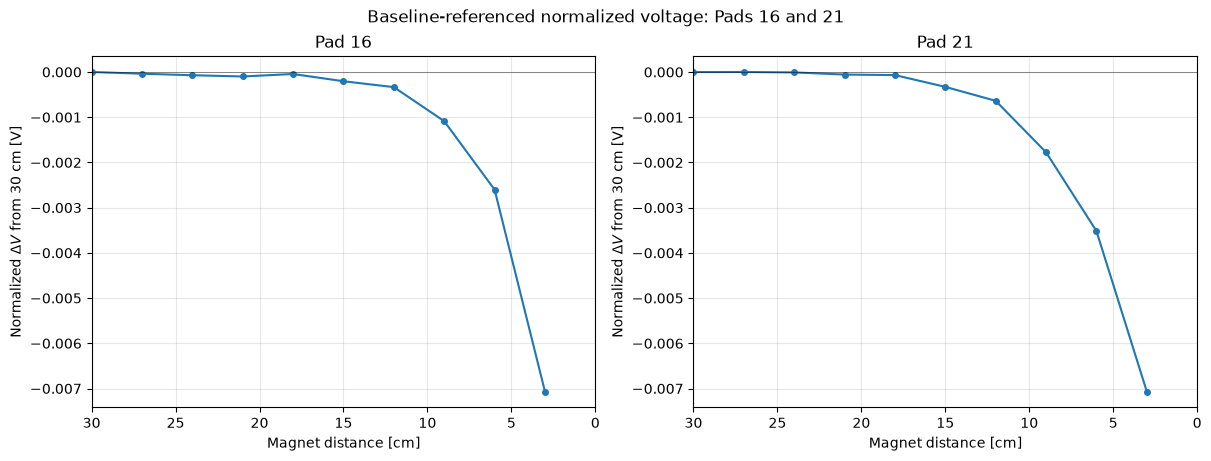

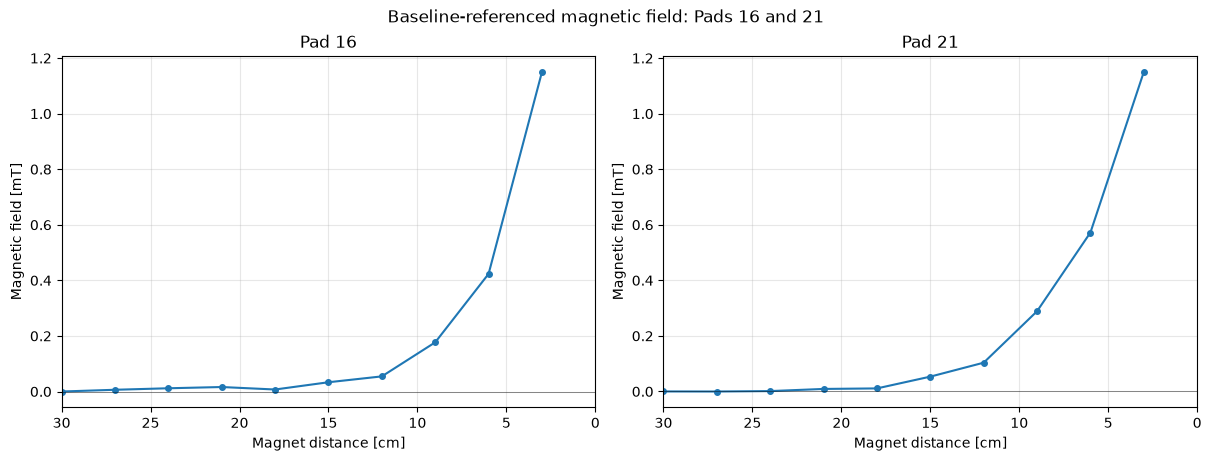

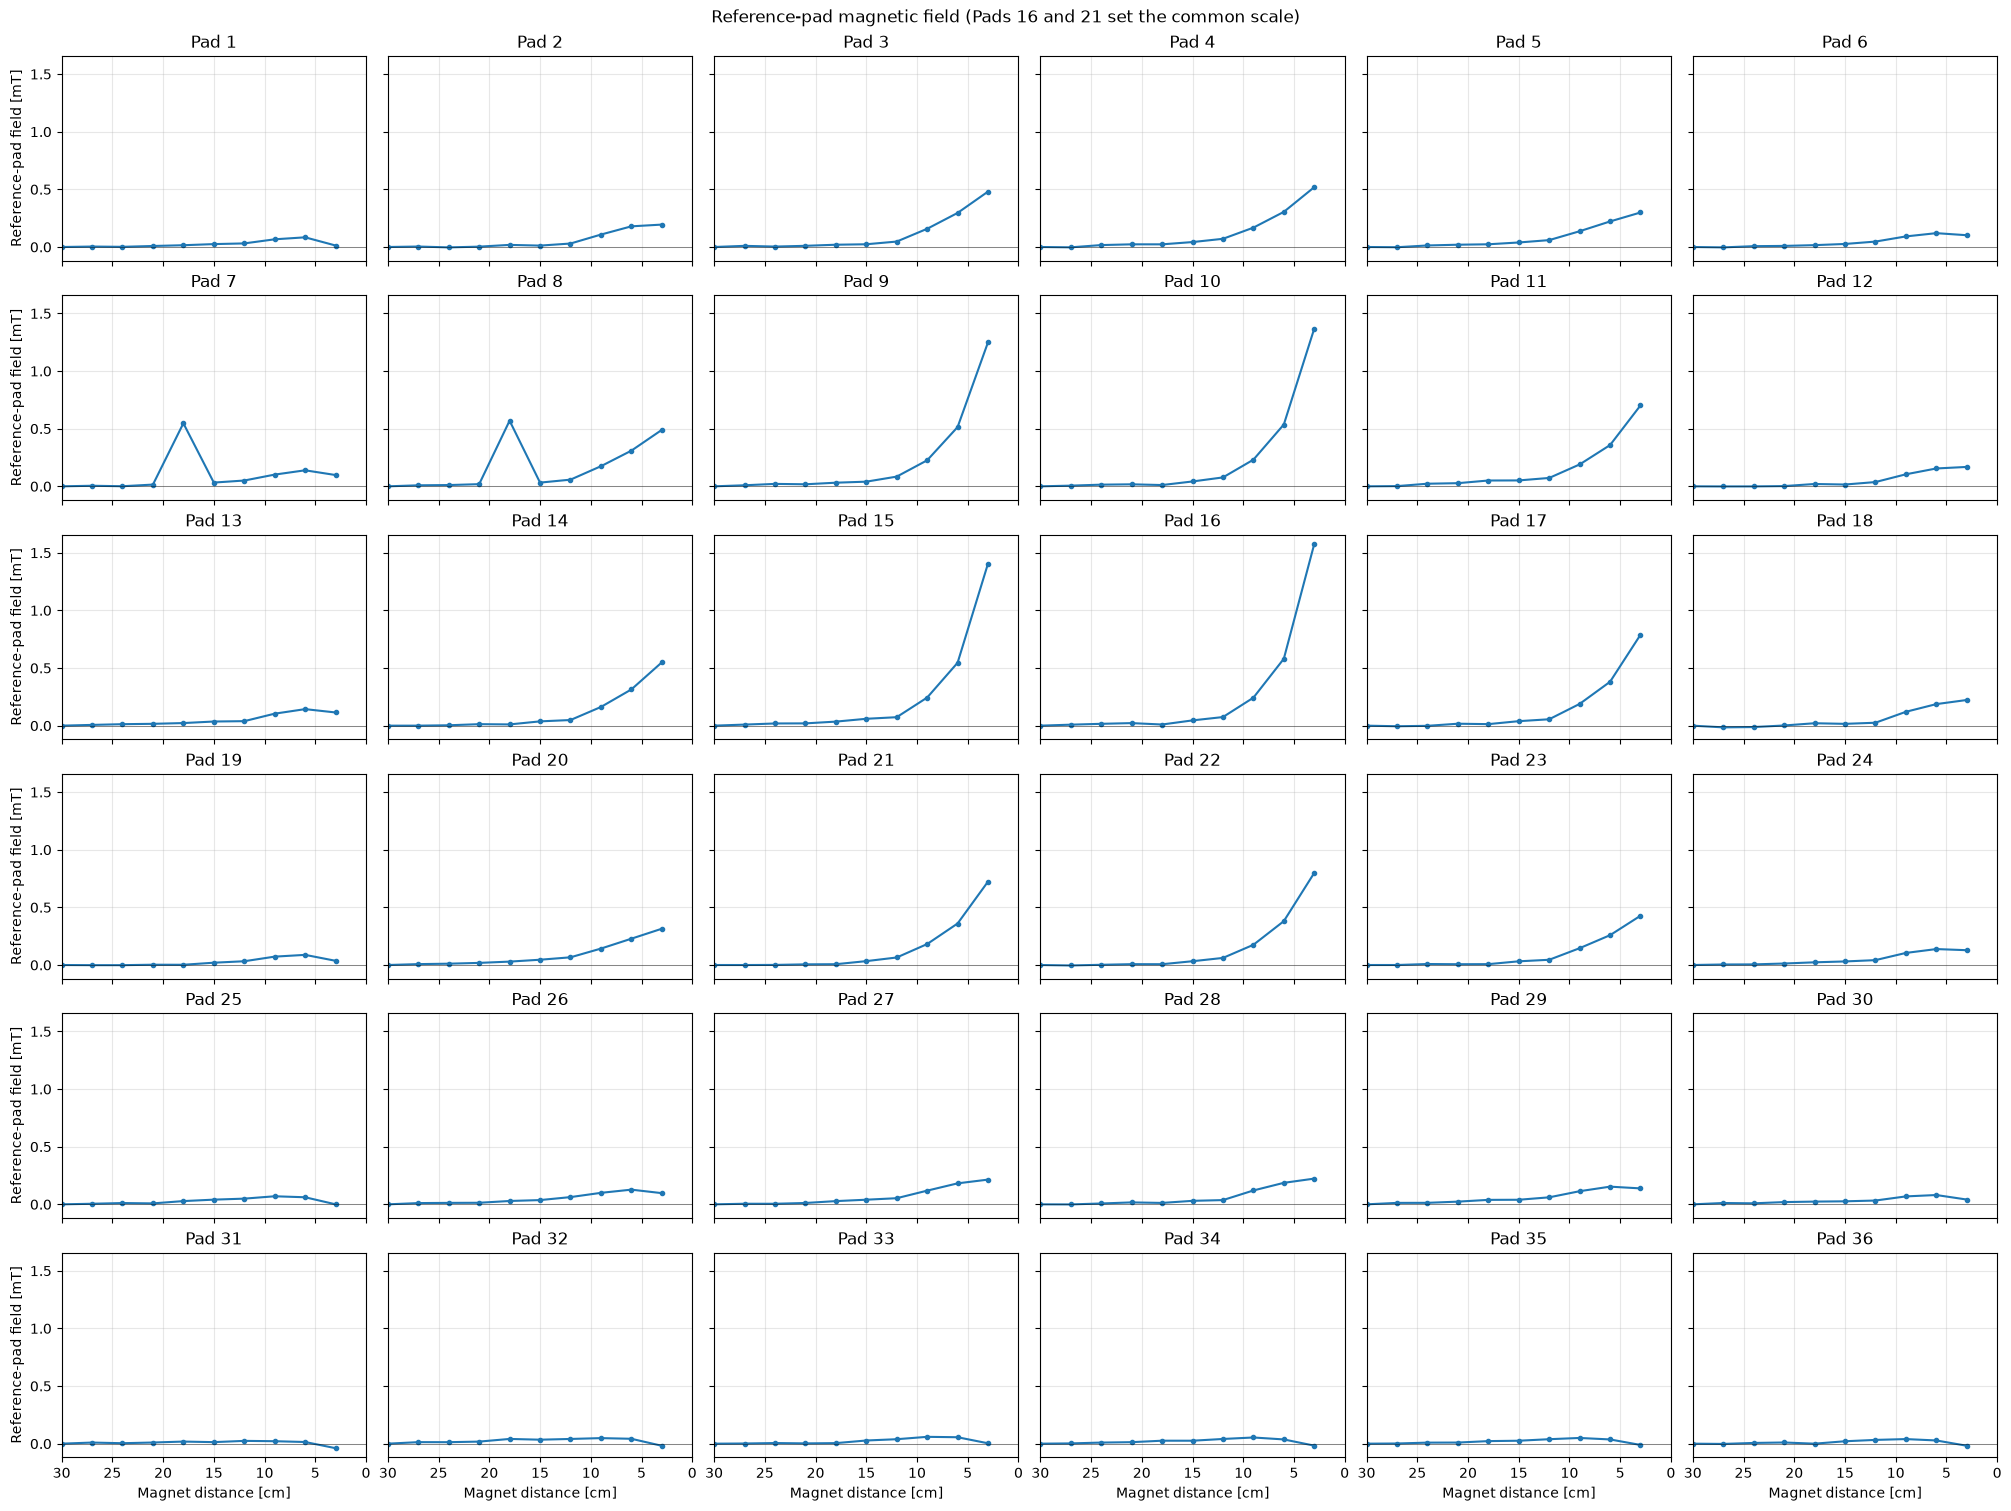

Saved hall_array_output/hall_array_raw_normalized_field.csv
Saved hall_array_output/hall_array_normalization_factors.csv
Saved hall_array_output/hall_array_magnetic_field_by_pad.csv
Saved hall_array_output/hall_array_reference_pad_field_by_pad.csv
Saved hall_array_output/magnetic_field_sensitivity_vs_distance.png
Saved hall_array_output/normalized_voltage_vs_distance.png
Saved hall_array_output/magnetic_field_vs_distance.png
Saved hall_array_output/pads_16_21_raw_voltage_vs_distance.png
Saved hall_array_output/pads_16_21_normalized_voltage_vs_distance.png
Saved hall_array_output/pads_16_21_magnetic_field_vs_distance.png
Saved hall_array_output/reference_pad_magnetic_field_vs_distance.png
At 30 cm: normalized voltage and B are zero. At 3 cm: a_plus = -0.00706629778 V corresponds to 1.15 mT.
Alternative reference-pad scale: Pads (16, 21), -52.6281988 mT/V.
Each distance was recorded every 2 seconds using frames from the final 1 second(s) of each interval.


In [28]:
# Magnetic-field sensitivity sweep for a 6 x 6 Hall array.
# Every two seconds, the code records the current distance and prints the next
# distance so the operator knows when to lower the magnet by 3 cm.
# Frames from the second half of each two-second interval are averaged to reduce
# ADC noise while still allowing one second for magnet movement and settling.

SENSITIVITY_START_CM = 30
SENSITIVITY_STOP_CM = 3
SENSITIVITY_STEP_INTERVAL_S = 2.0
SENSITIVITY_SETTLE_BEFORE_AVERAGING_S = 1.0
SENSITIVITY_FRAME_TIMEOUT_S = 5
SENSITIVITY_BASELINE_FRAMES = 500
SENSITIVITY_DISPLAY_WINDOW_FRAMES = 64


def read_one_raw_frame(ser, parser, timeout_s):
    """Return the first complete transmitted frame received after this call."""
    deadline = time.perf_counter() + timeout_s
    while time.perf_counter() < deadline:
        chunk = ser.read(max(ser.in_waiting, 1))
        if not chunk:
            continue
        frames = parser.feed(chunk)
        if frames:
            return frames[0]
    raise TimeoutError(
        f"No complete Hall-array frame received within {timeout_s:.1f} s. "
        "Check the serial connection and firmware stream."
    )


sensitivity_distance_cm = np.arange(
    SENSITIVITY_START_CM, SENSITIVITY_STOP_CM - 1, -3, dtype=np.float64
)
sensitivity_wire_values = []

# Non-blocking reads keep the live display responsive at the frame rate.
with serial.Serial(PORT, BAUDRATE, timeout=0) as ser:
    # The display follows timeseries_ambient.py: baseline reference plus a
    # rolling display average. It does not alter the raw saved measurements.
    global sensitivity_live_viewer
    sensitivity_live_viewer = SensitivityLiveSignalWindow(
        "Live Hall-array signals — magnetic-field sensitivity sweep",
        calibration_frames=SENSITIVITY_BASELINE_FRAMES,
        display_window_frames=SENSITIVITY_DISPLAY_WINDOW_FRAMES,
    )
    live_parser = FrameParser()
    print("Keep the magnet at 50 cm while the live-display baseline is collected.")
    while not sensitivity_live_viewer.calibrated:
        chunk = ser.read(max(ser.in_waiting, 1))
        if chunk:
            for raw_frame in live_parser.feed(chunk):
                sensitivity_live_viewer.update(raw_frame)
        else:
            time.sleep(0.001)
    number_of_distances = len(sensitivity_distance_cm)
    for step_number, distance_cm in enumerate(sensitivity_distance_cm, start=1):
        print(
            f"[{step_number}/{number_of_distances}] MOVE magnet to "
            f"{distance_cm:.0f} cm NOW. Recording in "
            f"{SENSITIVITY_STEP_INTERVAL_S:g} seconds...",
            flush=True,
        )

        interval_start = time.perf_counter()
        averaging_start = (
            interval_start + SENSITIVITY_SETTLE_BEFORE_AVERAGING_S
        )
        interval_deadline = interval_start + SENSITIVITY_STEP_INTERVAL_S
        frames_for_average = []

        # Continue updating the live window throughout the two-second interval.
        # Only frames received after the settling period are used in the saved
        # measurement for this distance.
        while time.perf_counter() < interval_deadline:
            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                for raw_frame in live_parser.feed(chunk):
                    sensitivity_live_viewer.update(raw_frame)
                    if time.perf_counter() >= averaging_start:
                        frames_for_average.append(
                            np.asarray(raw_frame, dtype=np.float64)
                        )
            else:
                # Yield briefly while preserving a responsive Qt event loop.
                time.sleep(0.001)

        # Normally many frames are available for averaging. If no frame arrived
        # during the averaging window, wait for one complete fallback frame.
        if frames_for_average:
            measurement_frame = np.mean(frames_for_average, axis=0)
        else:
            fallback_parser = FrameParser()
            measurement_frame = np.asarray(
                read_one_raw_frame(
                    ser,
                    fallback_parser,
                    SENSITIVITY_FRAME_TIMEOUT_S,
                ),
                dtype=np.float64,
            )
            sensitivity_live_viewer.update(measurement_frame)

        sensitivity_wire_values.append(measurement_frame)
        print(
            f"Recorded {distance_cm:.0f} cm using "
            f"{max(len(frames_for_average), 1)} frame(s).",
            flush=True,
        )

# Close the live-display window automatically after the 3 cm sample.
sensitivity_live_viewer.close()

sensitivity_wire_values = np.asarray(sensitivity_wire_values, dtype=np.float64)
sensitivity_voltage_v = (
    sensitivity_wire_values / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
)

# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Advisor's baseline-referenced normalization and one-point field calibration
# (all 36 pads)
# ---------------------------------------------------------------------------
# First use each pad's 30 cm raw voltage as zero:
#
#                 delta_V_i(d) = V_raw_i(d) - V_raw_i(30 cm).
#
# At 3 cm, define a_i as this baseline-referenced voltage of pad i. The common
# target value is
#
#                 a_plus = (1 / 36) * sum_i(a_i).
#
# Normalize each pad with c_i = a_plus / a_i:
#
#                 V_norm_i(d) = c_i * delta_V_i(d).
#
# This makes every pad 0 V at 30 cm and equal to a_plus at 3 cm. The stated
# calibration is a_plus <-> 1.15 mT, therefore
#
#                 B_i(d) = V_norm_i(d) * 1.15 mT / a_plus.
#
# This is the requested formula with the advisor's 30 cm baseline.
BASELINE_DISTANCE_CM = 30.0
CALIBRATION_DISTANCE_CM = 3.0
CALIBRATION_FIELD_MT = 1.15

baseline_rows = np.flatnonzero(
    np.isclose(sensitivity_distance_cm, BASELINE_DISTANCE_CM)
)
calibration_rows = np.flatnonzero(
    np.isclose(sensitivity_distance_cm, CALIBRATION_DISTANCE_CM)
)
if baseline_rows.size != 1:
    raise RuntimeError(
        f"Expected exactly one measurement at {BASELINE_DISTANCE_CM:g} cm; "
        f"found {baseline_rows.size}."
    )
if calibration_rows.size != 1:
    raise RuntimeError(
        f"Expected exactly one measurement at {CALIBRATION_DISTANCE_CM:g} cm; "
        f"found {calibration_rows.size}."
    )

baseline_row = baseline_rows[0]
calibration_row = calibration_rows[0]
baseline_voltage_by_pad_v = sensitivity_voltage_v[baseline_row]
baseline_referenced_voltage_v = (
    sensitivity_voltage_v - baseline_voltage_by_pad_v[np.newaxis, :]
)
baseline_referenced_voltage_v[baseline_row, :] = 0.0

calibration_voltage_by_pad_v = baseline_referenced_voltage_v[calibration_row]
if np.any(~np.isfinite(calibration_voltage_by_pad_v)) or np.any(
    np.isclose(calibration_voltage_by_pad_v, 0.0, atol=1e-12)
):
    raise RuntimeError(
        "Each pad's baseline-referenced 3 cm voltage must be finite and nonzero. "
        "Re-measure if a pad has identical 30 cm and 3 cm readings."
    )

calibration_mean_voltage_v = calibration_voltage_by_pad_v.mean()  # a_plus
normalization_factor = calibration_mean_voltage_v / calibration_voltage_by_pad_v
normalized_voltage_v = (
    baseline_referenced_voltage_v * normalization_factor[np.newaxis, :]
)
normalized_voltage_v[baseline_row, :] = 0.0
magnetic_field_mt = (
    normalized_voltage_v * CALIBRATION_FIELD_MT / calibration_mean_voltage_v
)
magnetic_field_mt[baseline_row, :] = 0.0
magnetic_field_t = magnetic_field_mt * 1e-3
sensitivity_distance_m = sensitivity_distance_cm / 100.0

# Save raw voltage, baseline-referenced voltage, normalized voltage, and
# magnetic field for every pad.
sensitivity_csv_path = OUTPUT_DIR / "hall_array_raw_normalized_field.csv"
sensitivity_header = (
    "distance_cm,distance_m,mean_normalized_voltage_v,mean_magnetic_field_mt,"
    + ",".join(
        f"pad_{index:02d}_raw_voltage_v" for index in range(1, NUM_CHANNELS + 1)
    )
    + ","
    + ",".join(
        f"pad_{index:02d}_baseline_referenced_voltage_v"
        for index in range(1, NUM_CHANNELS + 1)
    )
    + ","
    + ",".join(
        f"pad_{index:02d}_normalized_voltage_v"
        for index in range(1, NUM_CHANNELS + 1)
    )
    + ","
    + ",".join(
        f"pad_{index:02d}_magnetic_field_mt"
        for index in range(1, NUM_CHANNELS + 1)
    )
)
np.savetxt(
    sensitivity_csv_path,
    np.column_stack(
        (
            sensitivity_distance_cm,
            sensitivity_distance_m,
            normalized_voltage_v.mean(axis=1),
            magnetic_field_mt.mean(axis=1),
            sensitivity_voltage_v,
            baseline_referenced_voltage_v,
            normalized_voltage_v,
            magnetic_field_mt,
        )
    ),
    delimiter=",",
    header=sensitivity_header,
    comments="",
)

# Save the 30 cm baseline, a_i, a_plus, and c_i so the normalization is
# reproducible.
normalization_csv_path = OUTPUT_DIR / "hall_array_normalization_factors.csv"
np.savetxt(
    normalization_csv_path,
    np.column_stack(
        (
            np.arange(1, NUM_CHANNELS + 1),
            baseline_voltage_by_pad_v,
            calibration_voltage_by_pad_v,
            normalization_factor,
            np.full(NUM_CHANNELS, calibration_mean_voltage_v),
            np.full(NUM_CHANNELS, CALIBRATION_FIELD_MT),
        )
    ),
    delimiter=",",
    header=(
        "pad,raw_voltage_at_30cm_v,baseline_referenced_voltage_at_3cm_v,"
        "normalization_factor,"
        "target_normalized_voltage_v,calibration_field_mt"
    ),
    comments="",
)

# Save a compact magnetic-field-only table: one row per distance and one column
# per Hall pad.  This is redundant with the combined CSV above, but makes the
# field result easy to import into Excel or give directly to the advisor.
magnetic_field_csv_path = OUTPUT_DIR / "hall_array_magnetic_field_by_pad.csv"
magnetic_field_header = "distance_cm,distance_m," + ",".join(
    f"pad_{index:02d}_magnetic_field_mt" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(
    magnetic_field_csv_path,
    np.column_stack(
        (sensitivity_distance_cm, sensitivity_distance_m, magnetic_field_mt)
    ),
    delimiter=",",
    header=magnetic_field_header,
    comments="",
)

# ---------------------------------------------------------------------------
# OPTIONAL ALTERNATIVE: reference-pad calibration, without per-pad equalizing.
#
# The original normalization above forces every pad to have the same 3 cm
# response. That is useful only when every pad experiences the same known field
# during calibration. When the magnet is localized over Pads 16 and 21, it
# removes the real spatial difference between pads and magnifies noisy pads.
#
# This alternative keeps each pad's actual baseline-referenced response. It
# uses only Pads 16 and 21 to obtain ONE common V-to-mT scale at 3 cm:
#
#     scale [mT/V] = 1.15 mT / mean(Delta V_16(3 cm), Delta V_21(3 cm))
#     B_i(d) = Delta V_i(d) * scale
#
# The mean field of Pads 16 and 21 at 3 cm becomes 1.15 mT; other pads are not
# artificially forced to 1.15 mT. Change these pad numbers if the magnet is
# intentionally centred over another location.
REFERENCE_PADS_FOR_ALTERNATIVE = (16, 21)
reference_indices = np.asarray(REFERENCE_PADS_FOR_ALTERNATIVE, dtype=int) - 1
if np.any(reference_indices < 0) or np.any(reference_indices >= NUM_CHANNELS):
    raise ValueError("REFERENCE_PADS_FOR_ALTERNATIVE must contain pad numbers 1-36.")

reference_response_at_3cm_v = calibration_voltage_by_pad_v[reference_indices].mean()
if not np.isfinite(reference_response_at_3cm_v) or np.isclose(
    reference_response_at_3cm_v, 0.0, atol=1e-12
):
    raise RuntimeError(
        "The mean 3 cm response of the alternative reference pads is zero or invalid."
    )

alternative_field_scale_mt_per_v = (
    CALIBRATION_FIELD_MT / reference_response_at_3cm_v
)
alternative_field_mt = (
    baseline_referenced_voltage_v * alternative_field_scale_mt_per_v
)
alternative_field_mt[baseline_row, :] = 0.0

alternative_field_csv_path = OUTPUT_DIR / "hall_array_reference_pad_field_by_pad.csv"
alternative_field_header = (
    "distance_cm,distance_m," + ",".join(
        f"pad_{index:02d}_baseline_referenced_voltage_v"
        for index in range(1, NUM_CHANNELS + 1)
    ) + "," + ",".join(
        f"pad_{index:02d}_reference_pad_field_mt"
        for index in range(1, NUM_CHANNELS + 1)
    )
)
np.savetxt(
    alternative_field_csv_path,
    np.column_stack(
        (
            sensitivity_distance_cm,
            sensitivity_distance_m,
            baseline_referenced_voltage_v,
            alternative_field_mt,
        )
    ),
    delimiter=",",
    header=alternative_field_header,
    comments="",
)

# One panel per pad: natural raw output voltage versus magnet-to-array distance.
fig, axes = plt.subplots(
    6, 6, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=True
)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, sensitivity_voltage_v[:, channel], marker="o", ms=3)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Natural $V_{out}$ [V]")
# Set the shared X-axis once: 30 cm at left, 0 cm at right.
axes[0, 0].set_xlim(SENSITIVITY_START_CM, 0.0)
fig.suptitle("Raw Hall-array output versus magnet distance (averaged per step)")
sensitivity_distance_plot_path = OUTPUT_DIR / "magnetic_field_sensitivity_vs_distance.png"
fig.savefig(sensitivity_distance_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# One panel per pad: baseline-referenced normalized voltage.
fig, axes = plt.subplots(
    6, 6, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=True
)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, normalized_voltage_v[:, channel], marker="o", ms=3)
    ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Normalized $\Delta V$ from 30 cm [V]")
axes[0, 0].set_xlim(SENSITIVITY_START_CM, 0.0)
fig.suptitle("Baseline-referenced normalized Hall-array voltage")
normalized_voltage_plot_path = OUTPUT_DIR / "normalized_voltage_vs_distance.png"
fig.savefig(normalized_voltage_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# One panel per pad: magnetic field from the stated 3 cm calibration.
fig, axes = plt.subplots(
    6, 6, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=True
)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, magnetic_field_mt[:, channel], marker="o", ms=3)
    ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel("Magnetic field [mT]")
axes[0, 0].set_xlim(SENSITIVITY_START_CM, 0.0)
fig.suptitle("Baseline-referenced Hall-array magnetic field")
field_plot_path = OUTPUT_DIR / "magnetic_field_vs_distance.png"
fig.savefig(field_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# Focused diagnostic plots for the two pads nearest the magnet.  These use
# independent y-axes, so an outlier in another pad cannot flatten their traces.
FOCUSED_PADS = (16, 21)  # Human pad numbers; array columns are pad - 1.

def save_focused_pad_plot(values, y_label, title, output_name, zero_line=False):
    """Save a two-panel plot for Pads 16 and 21 without altering 6x6 plots."""
    fig, axes = plt.subplots(1, len(FOCUSED_PADS), figsize=(12, 4.5),
                             sharex=True, constrained_layout=True)
    for pad, ax in zip(FOCUSED_PADS, axes):
        ax.plot(sensitivity_distance_cm, values[:, pad - 1], marker="o", ms=4)
        if zero_line:
            ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
        ax.set_title(f"Pad {pad}")
        ax.set_xlabel("Magnet distance [cm]")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        # 30 cm is at the left; the measured 3 cm point is at the right.
        ax.set_xlim(SENSITIVITY_START_CM, 0.0)
    fig.suptitle(title)
    output_path = OUTPUT_DIR / output_name
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    return output_path

focused_raw_plot_path = save_focused_pad_plot(
    sensitivity_voltage_v,
    r"Natural $V_{out}$ [V]",
    "Raw Hall-array output: Pads 16 and 21",
    "pads_16_21_raw_voltage_vs_distance.png",
)
focused_normalized_plot_path = save_focused_pad_plot(
    normalized_voltage_v,
    r"Normalized $\Delta V$ from 30 cm [V]",
    "Baseline-referenced normalized voltage: Pads 16 and 21",
    "pads_16_21_normalized_voltage_vs_distance.png",
    zero_line=True,
)
focused_field_plot_path = save_focused_pad_plot(
    magnetic_field_mt,
    "Magnetic field [mT]",
    "Baseline-referenced magnetic field: Pads 16 and 21",
    "pads_16_21_magnetic_field_vs_distance.png",
    zero_line=True,
)

# Display the alternative field estimate separately, without overwriting any
# original plot. It preserves spatial differences between all 36 pads.
fig, axes = plt.subplots(
    6, 6, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=True
)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, alternative_field_mt[:, channel], marker="o", ms=3)
    ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel("Reference-pad field [mT]")
axes[0, 0].set_xlim(SENSITIVITY_START_CM, 0.0)
fig.suptitle("Reference-pad magnetic field (Pads 16 and 21 set the common scale)")
alternative_field_plot_path = OUTPUT_DIR / "reference_pad_magnetic_field_vs_distance.png"
fig.savefig(alternative_field_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {sensitivity_csv_path}")
print(f"Saved {normalization_csv_path}")
print(f"Saved {magnetic_field_csv_path}")
print(f"Saved {alternative_field_csv_path}")
print(f"Saved {sensitivity_distance_plot_path}")
print(f"Saved {normalized_voltage_plot_path}")
print(f"Saved {field_plot_path}")
print(f"Saved {focused_raw_plot_path}")
print(f"Saved {focused_normalized_plot_path}")
print(f"Saved {focused_field_plot_path}")
print(f"Saved {alternative_field_plot_path}")
print(
    f"At {BASELINE_DISTANCE_CM:g} cm: normalized voltage and B are zero. "
    f"At {CALIBRATION_DISTANCE_CM:g} cm: a_plus = "
    f"{calibration_mean_voltage_v:.9g} V corresponds to "
    f"{CALIBRATION_FIELD_MT:g} mT."
)
print(
    "Alternative reference-pad scale: "
    f"Pads {REFERENCE_PADS_FOR_ALTERNATIVE}, "
    f"{alternative_field_scale_mt_per_v:.9g} mT/V."
)
print(
    "Each distance was recorded every "
    f"{SENSITIVITY_STEP_INTERVAL_S:g} seconds using frames from the final "
    f"{SENSITIVITY_STEP_INTERVAL_S - SENSITIVITY_SETTLE_BEFORE_AVERAGING_S:g} "
    "second(s) of each interval."
)
